# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Load the MNase data for a cycling window:

from src.chromatin_model import read_chromosome_mnase_reads
from src.global_config import GlobalConstants

chr_reads = read_chromosome_mnase_reads(chr=16, replicate=1)
mnase_span = (771600, 771900)

locus_reads = chr_reads[(chr_reads.mid > mnase_span[0]) & 
                        (chr_reads.mid < mnase_span[1])]


In [5]:
from src.chromatin_model import create_exact_bins, downsample_bins, normalize_bins_by_len

timepoints = GlobalConstants.CHROM_WT1_TIMEPOINTS
exact_bins = create_exact_bins(locus_reads, mnase_span, timepoints)
normalized_bins = normalize_bins_by_len(1, exact_bins, log=False)


In [6]:
downsampled_bins = downsample_bins(normalized_bins, mnase_span, GlobalConstants.BIN_WIDTH, 
    GlobalConstants.BIN_HEIGHT, GlobalConstants.MAX_Y_LEN, timepoints)

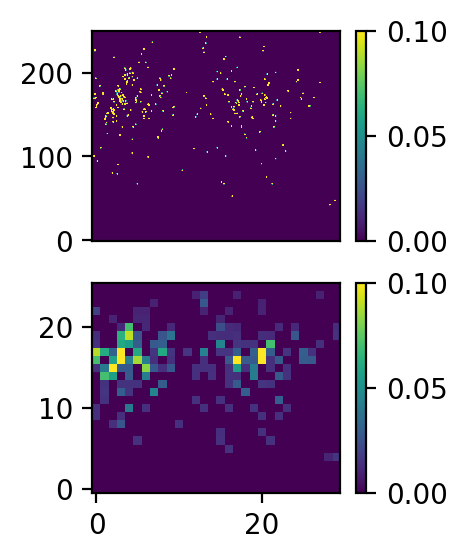

In [7]:
fig = plt.figure(figsize=(2, 3))
plt.subplot(2, 1, 1)
plt.imshow(exact_bins[0], vmax=0.1, vmin=0, aspect='auto', origin='lower')
plt.colorbar()
plt.xticks([])

plt.subplot(2, 1, 2)
plt.imshow(downsampled_bins[0], vmax=0.1, vmin=0, aspect='auto', origin='lower')
plt.colorbar()

In [8]:
from src.deconvolution_solver import DeconvolutionSolver
from src.config import load_default_chrom_configs
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

config, _ = load_default_chrom_configs()
#config.shift_parameters_for_alpha()

config.params_dic.update({
    'mu0': 9.361663,
    'lambda': 60.397553,
    'delta': 14.577271,
    'sigma0': 5.884135,
    'sigmav': 0.044401,
    'gamma1': 0.586077,
    'gamma2': 1.000000,
    'halted': 0.000050,  
})

config.update_timepoints()
H = config.calculate_H()

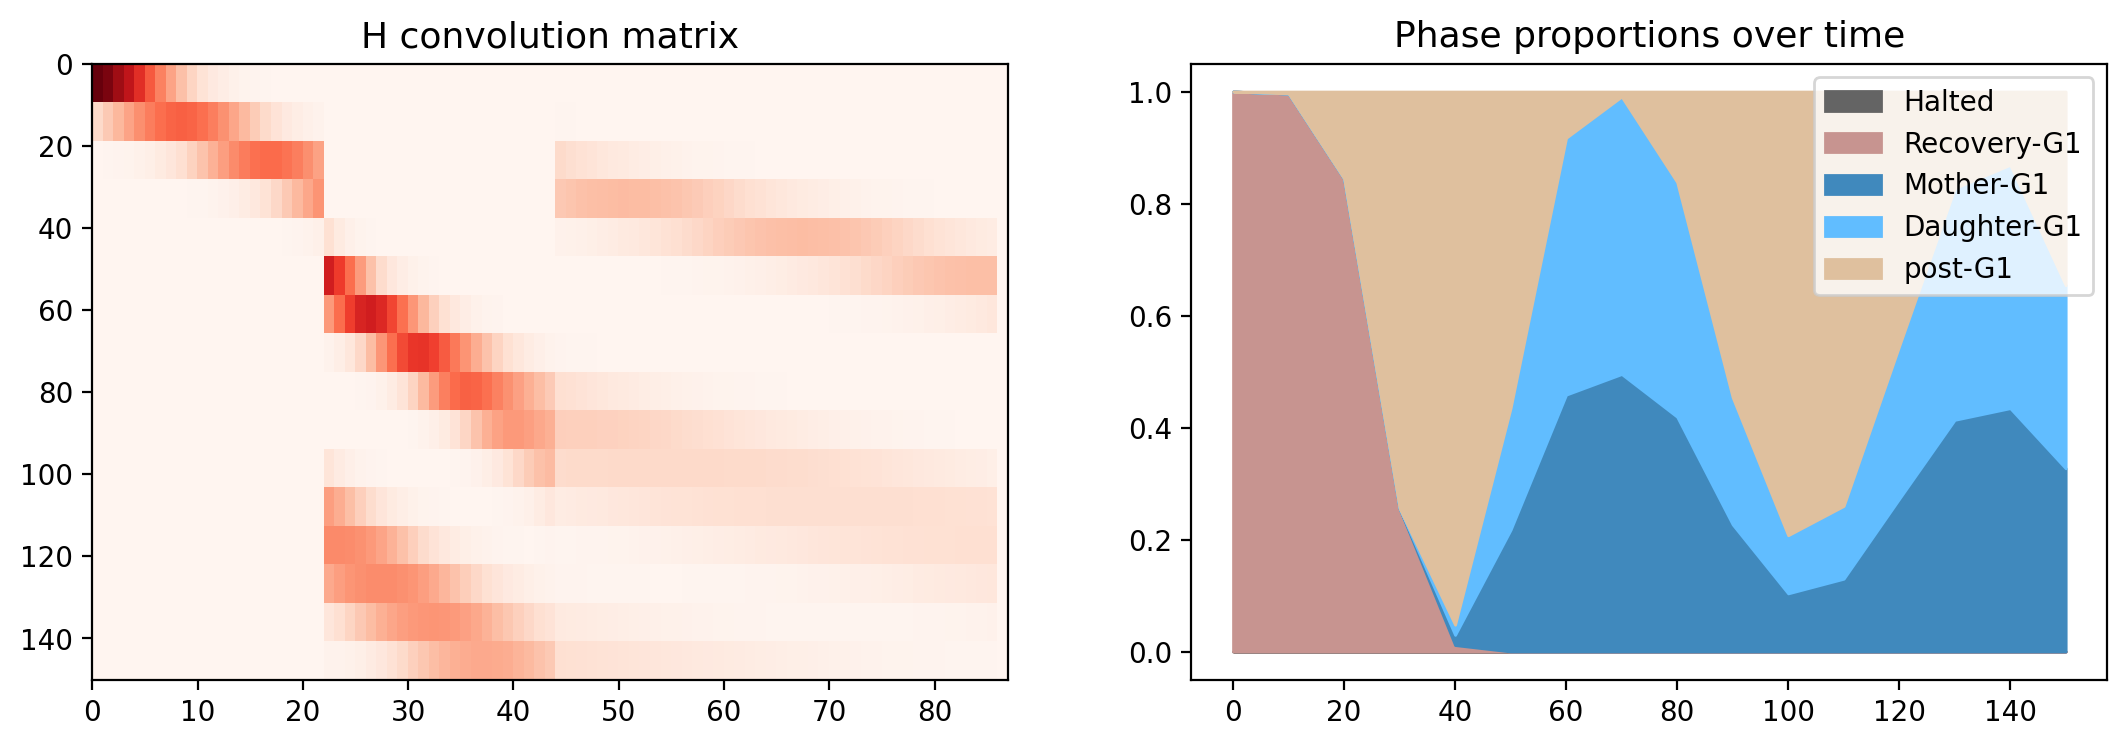

In [9]:
config.plot_H()

In [290]:
padding_type = 'both'

b = 1

chr4_n = np.array([1.00442364, 1.00347336, 0.97773201, 0.8061213 , 0.66388052,
       0.84322967, 0.99955218, 1.00893152, 0.97884289, 0.85742082,
       0.75599297, 0.76982516, 0.84182678, 0.97059662, 0.99078551,
       0.91119956])

N = np.diag(chr4_n)

f_rep = np.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 1.])

G = downsampled_bins.reshape((downsampled_bins.shape[0], -1))

In [793]:
G_max_df = pd.DataFrame({'max_value': G.max(axis=0), 'index': np.arange(G.shape[1])})
highest_Gs = G_max_df.sort_values('max_value', ascending=False).head(10)
highest_Gs

,max_value,index
513,0.287663,513
483,0.231483,483
452,0.206221,452
544,0.173763,544
485,0.170547,485
574,0.168654,574
493,0.160306,493
497,0.149229,497
482,0.149229,482
757,0.141448,757


In [794]:
G = downsampled_bins.reshape((downsampled_bins.shape[0], -1))
highest_indices = G.argmax(axis=1)
print("Indices with the highest max value: ", highest_indices)
selected_indices = highest_Gs.index.values
selected_examples_G = G[:, selected_indices]

0

Indices with the highest max value:  [513 513 513 493 544 483 757 493 513 483 483 483 513 544 544 487]


0

In [802]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma

chromatin_solver = ChromatinDeconvolveSolver(config, config.H, 
    selected_examples_G, N, b, f_rep,
    padding_type='both')

chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver)

	Base error (γ=0):
		RN: 0.007040
		SN: 9.791632
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.00739157
			Absolute (e0 + 0.04): 0.0470396
			Chosen: 0.007392
		Right:
			Relative (1.40 * e0): 0.00985542
			Absolute (e0 + 0.32): 0.32704
			Chosen: 0.327040
	Searching for left boundary gamma...
		γ: 0.000505	rn: 0.0160	sn: 0.0441
		γ: 0.0002575	rn: 0.0136	sn: 0.0641
		γ: 0.00013375	rn: 0.0116	sn: 0.0916
		γ: 7.1875e-05	rn: 0.0105	sn: 0.1213
		γ: 4.09375e-05	rn: 0.0097	sn: 0.1703
		γ: 2.54688e-05	rn: 0.0088	sn: 0.2524
		γ: 1.77344e-05	rn: 0.0086	sn: 0.2896
		γ: 1.38672e-05	rn: 0.0083	sn: 0.3321
		γ: 1.19336e-05	rn: 0.0082	sn: 0.3510
		γ: 1.09668e-05	rn: 0.0082	sn: 0.3694
	Left boundary gamma found: 1.04834e-05
	Searching for right boundary gamma...
		γ: 0.000505242	rn: 0.0160	sn: 0.0441
		γ: 0.000752621	rn: 0.0176	sn: 0.0373
		γ: 0.00087631	rn: 0.0180	sn: 0.0356
		γ: 0.000938155	rn: 0.0183	sn: 0.0348
		γ: 0.000969078	rn: 0.0184	sn: 0.0343
		γ: 0.000984539	rn: 0.0185	sn: 0.0342
		

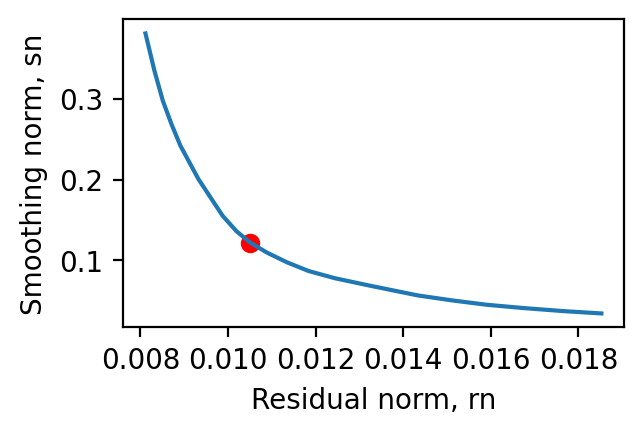

In [803]:
chrom_find_gamma.find_optimal_gamma()

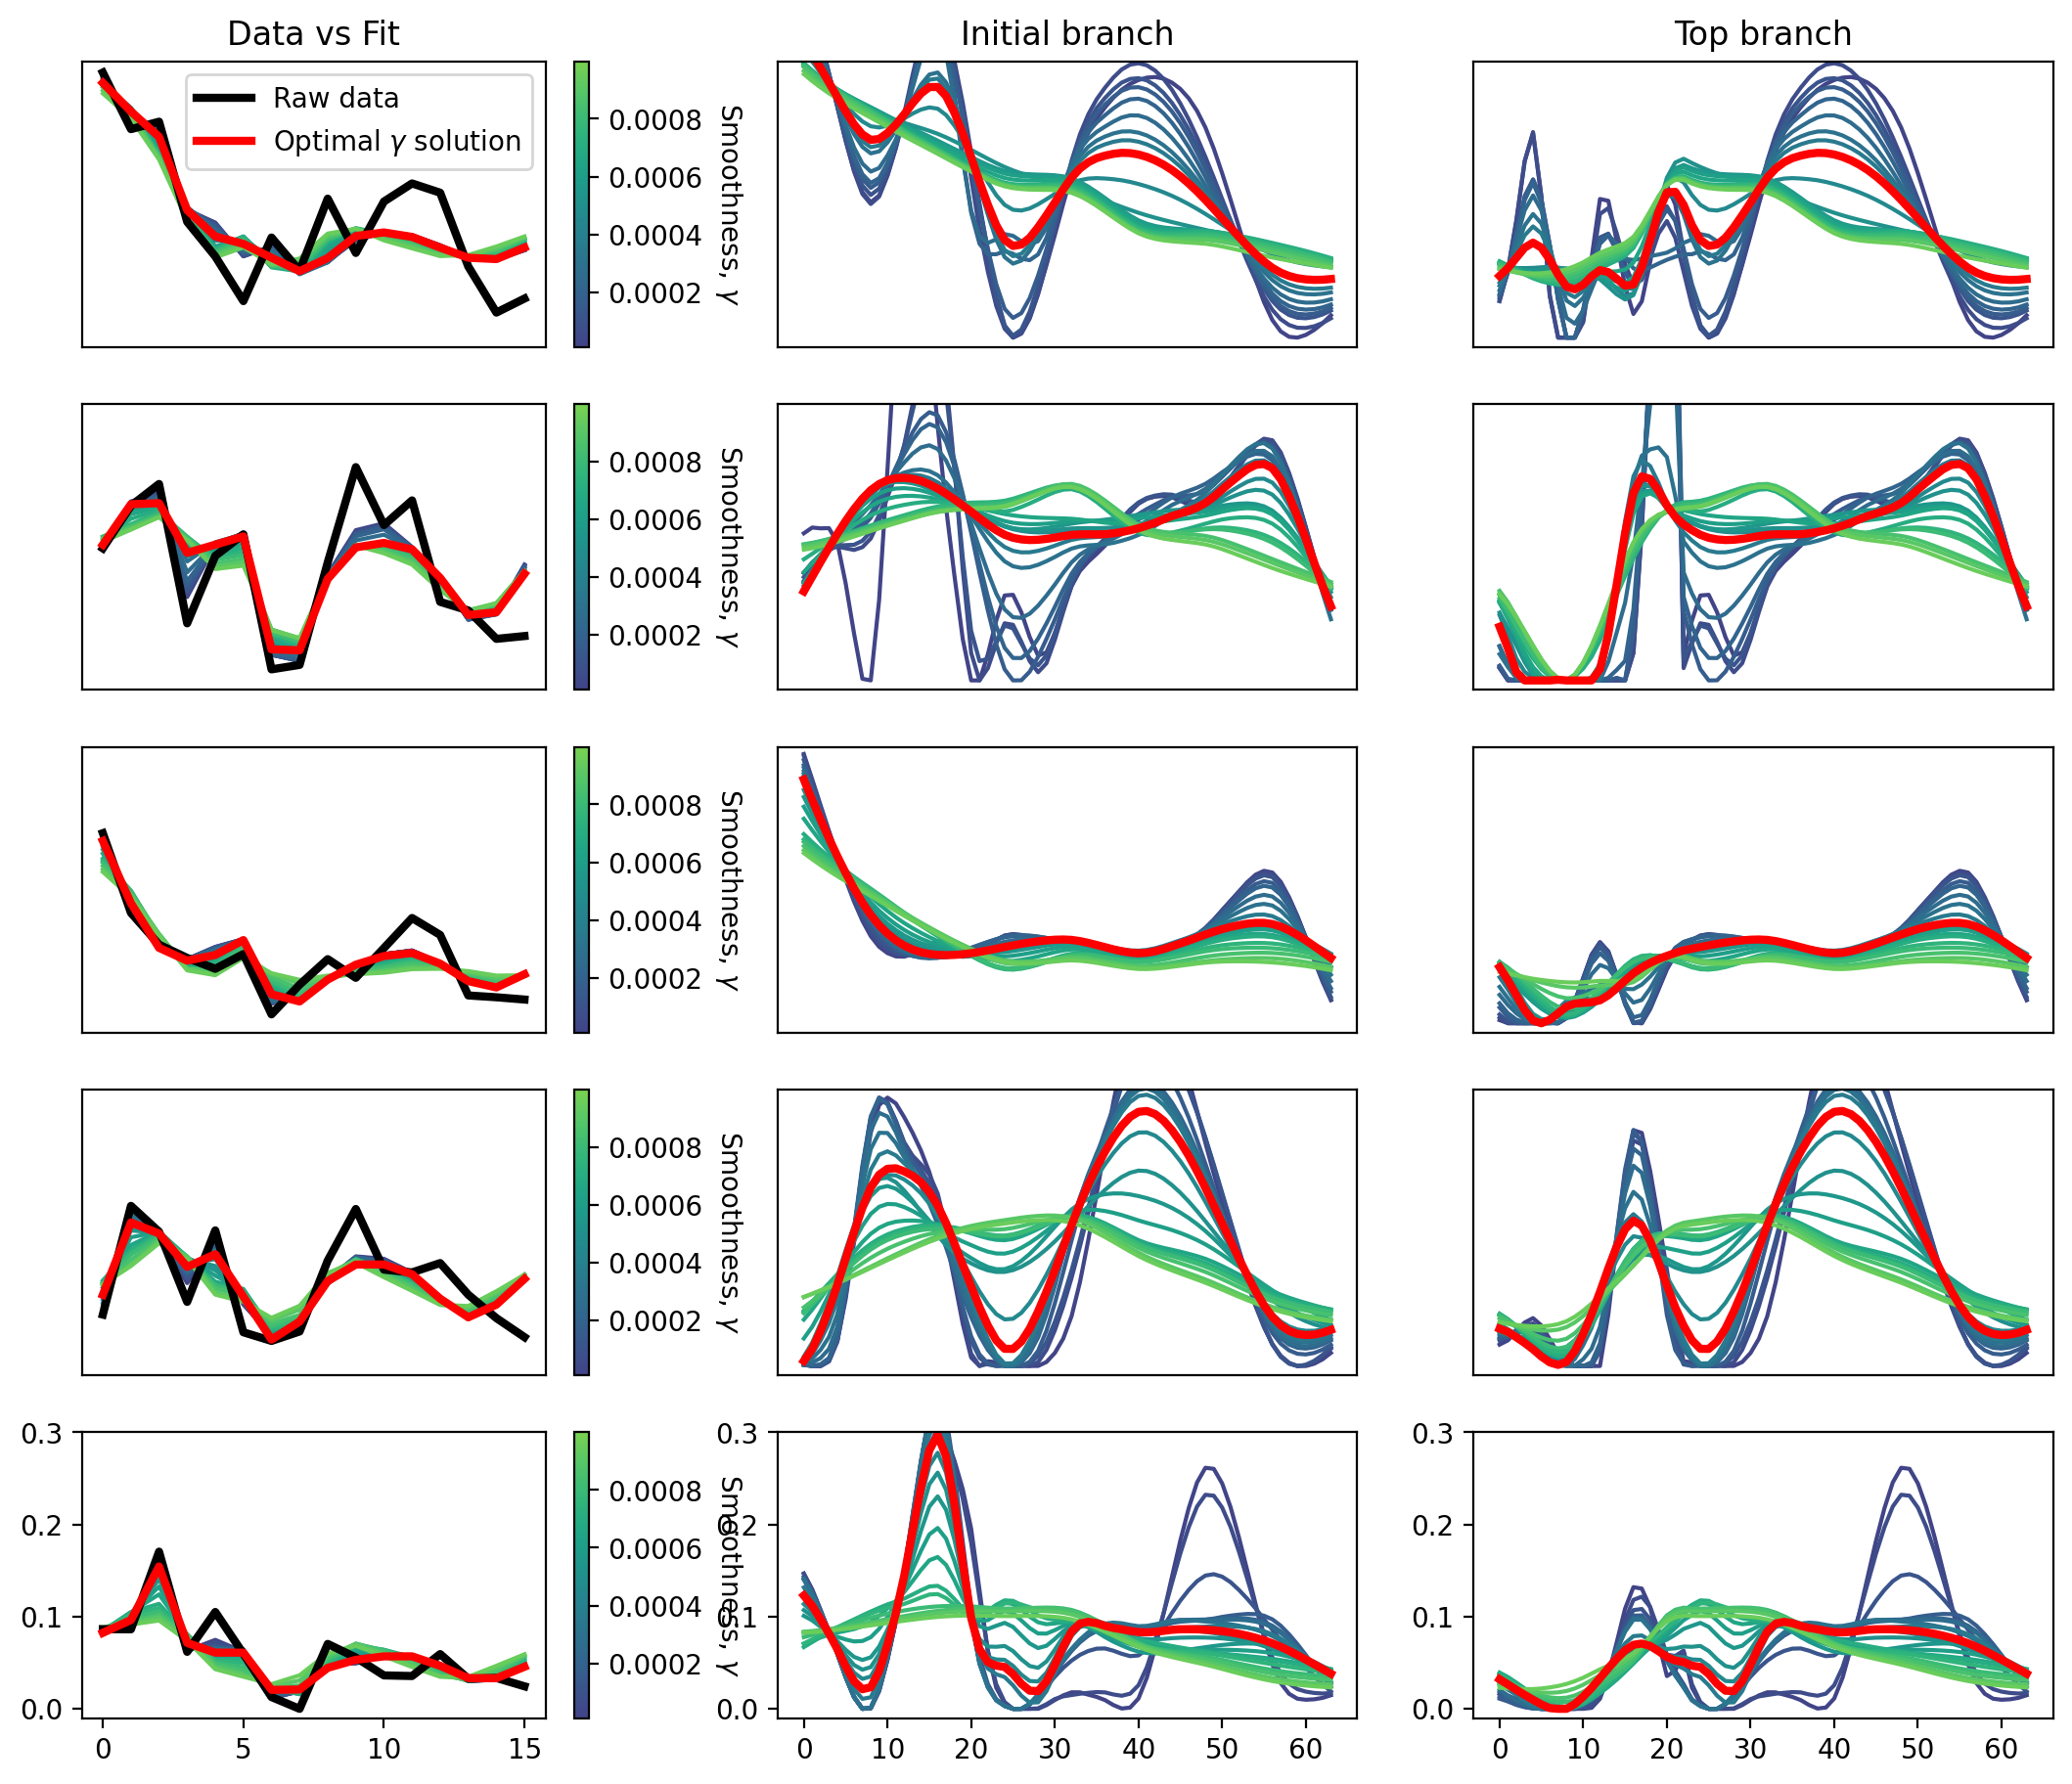

In [804]:
gamma_predicted_Gs_test = chrom_find_gamma.plot_gamma_sweep()

In [788]:
chromatin_solver_full = ChromatinDeconvolveSolver(config, config.H, 
    G, N, b, f_rep, padding_type=padding_type)
full_deconvolved_F = chromatin_solver_full.deconvolve_G_iteratively(
    gamma=chrom_find_gamma.gamma_optimizer.optimal_gamma)

0/780 - 00:00:00.001
500/780 - 00:01:25.549


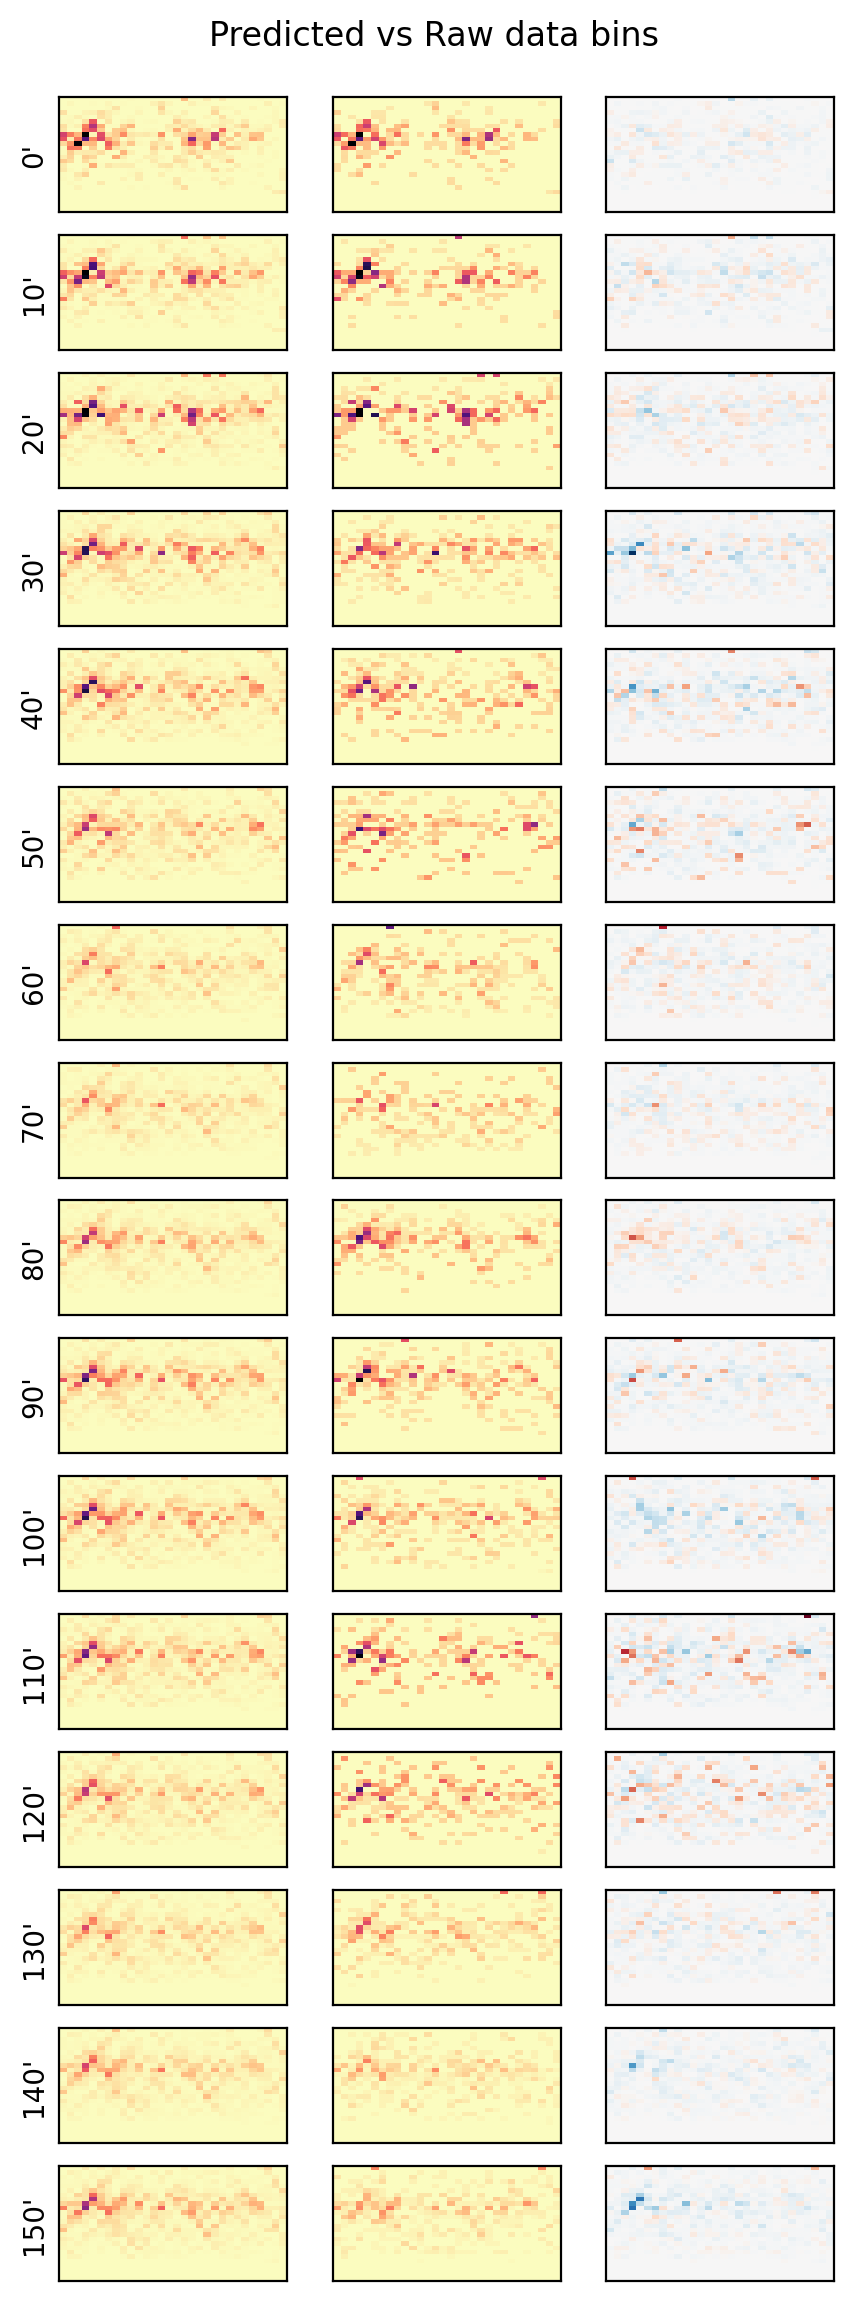

In [791]:
from src.chromatin_model import plot_prediction

plot_prediction(config, N, full_deconvolved_F, f_rep, G, b)

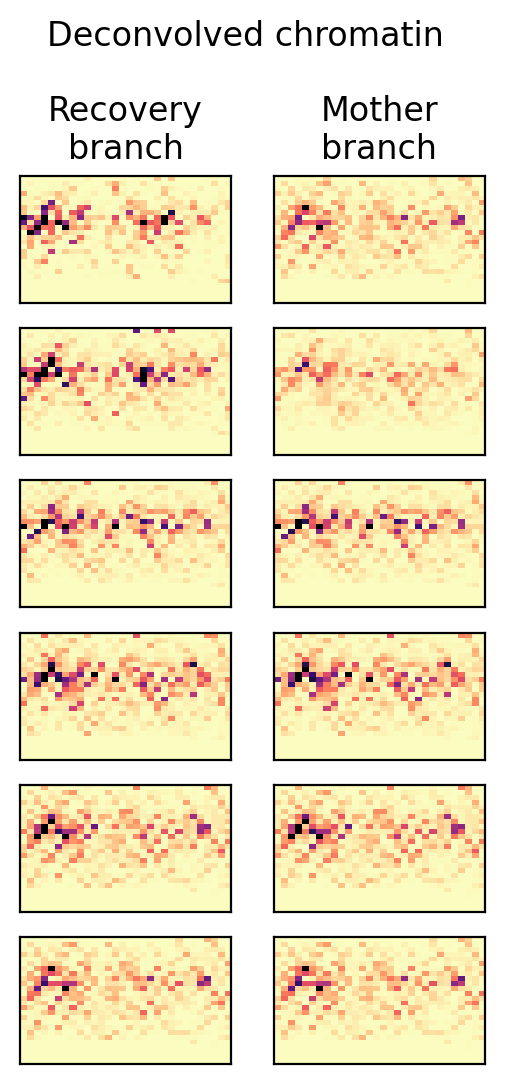

In [792]:

full_F_imgs = full_deconvolved_F.reshape((full_deconvolved_F.shape[0], 26, -1))
full_F_imgs.shape

num_imgs_per_branch = 6

fig, axs = plt.subplots(num_imgs_per_branch, 2, figsize=(3, 6))
axs = np.array(axs).T

def plot_branch_imgs(row_axs, t_indices):

    for plot_index, index_in_t in enumerate(np.linspace(0,
        len(t_indices)-1, num_imgs_per_branch)):
        image_index = t_indices[int(index_in_t)]

        ax = row_axs[plot_index]
        ax.imshow(full_F_imgs[image_index], aspect='auto', cmap='magma_r', vmax=0.1,
                  origin='lower')
        ax.set_xticks([])
        ax.set_yticks([])
        
plot_branch_imgs(axs[0], i_indices)
plot_branch_imgs(axs[1], t_indices)
axs[0][0].set_title("Recovery\nbranch")
axs[1][0].set_title("Mother\nbranch")
plt.suptitle("Deconvolved chromatin")
plt.subplots_adjust(top=0.85)